In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('adult.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (152, 15)
<class 'pandas.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             152 non-null    int64
 1   workclass       152 non-null    str  
 2   fnlwgt          152 non-null    int64
 3   education       152 non-null    str  
 4   education-num   152 non-null    int64
 5   marital-status  152 non-null    str  
 6   occupation      152 non-null    str  
 7   relationship    152 non-null    str  
 8   race            152 non-null    str  
 9   gender          152 non-null    str  
 10  capital-gain    152 non-null    int64
 11  capital-loss    152 non-null    int64
 12  hours-per-week  152 non-null    int64
 13  native-country  152 non-null    str  
 14  income          152 non-null    str  
dtypes: int64(6), str(9)
memory usage: 17.9 KB


In [4]:
df.dtypes.value_counts()

str      9
int64    6
Name: count, dtype: int64

In [5]:
target_column = 'income'
df[target_column].value_counts(dropna=False)

income
<=50K    79
>50K     73
Name: count, dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,152.000000,152.000000,152.000000,152.000000,152.0,152.000000
mean,36.381579,194433.750000,12.151316,445.703947,0.0,41.539474
std,9.044360,64701.829699,2.280815,2378.504956,0.0,7.750139
min,19.000000,19345.000000,4.000000,0.000000,0.0,13.000000
25%,30.000000,164526.000000,10.000000,0.000000,0.0,40.000000
50%,34.500000,190524.000000,13.000000,0.000000,0.0,40.000000
75%,42.250000,210198.000000,13.000000,0.000000,0.0,40.000000
max,59.000000,401851.000000,16.000000,15024.000000,0.0,80.000000


In [8]:
df.describe(include='object')

/var/folders/4d/bxl021h50qdcr6z35z1s85hm0000gn/T/ipykernel_8785/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,152,152,152,152,152,152,152,152,152
unique,7,11,5,12,5,3,2,7,2
top,Private,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,133,58,107,57,81,140,104,143,79


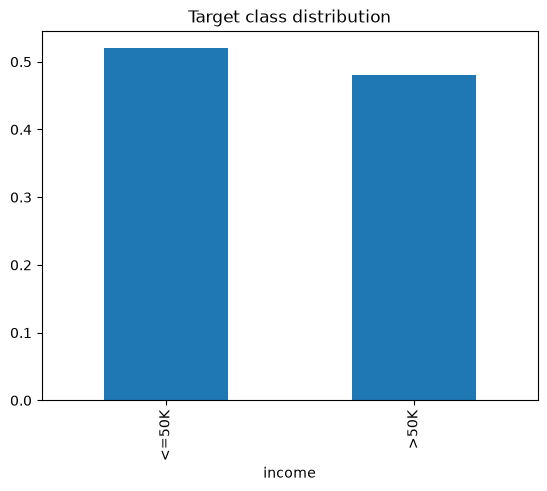

In [9]:
if df[target_column].dtype == 'object' or df[target_column].nunique() < 20:
    df[target_column].value_counts(normalize=True).plot(kind='bar')
    plt.title('Target class distribution')
    plt.show()

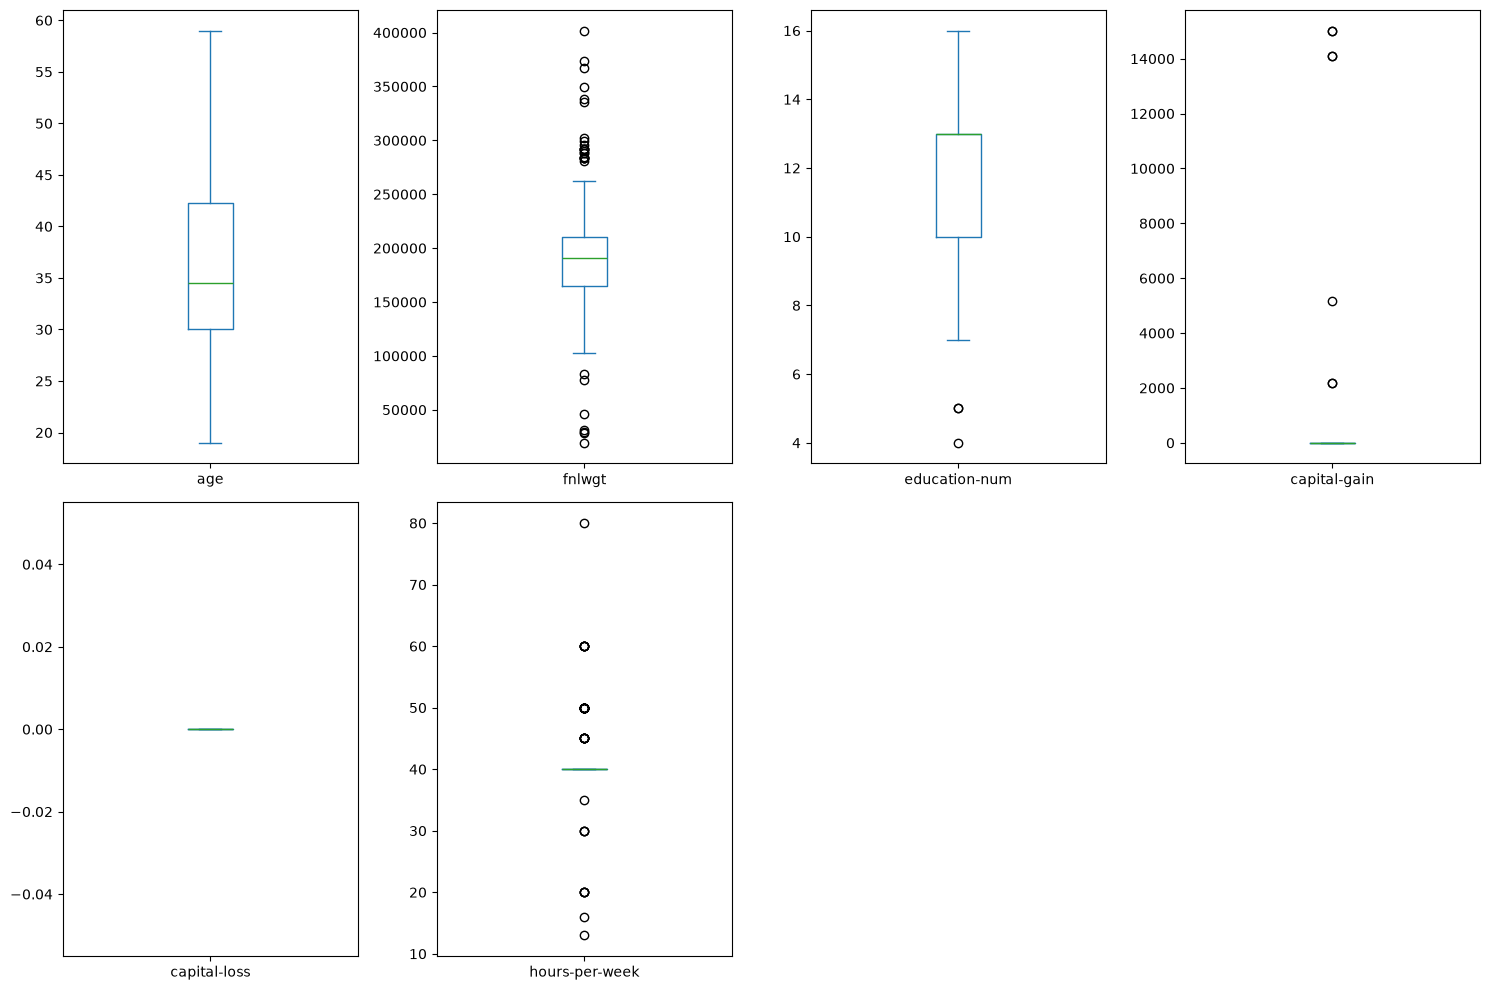

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if target_column in numeric_cols:
    numeric_cols.remove(target_column)

df[numeric_cols].plot(kind='box', subplots=True, layout=(len(numeric_cols)//4 + 1, 4),
                       figsize=(15, 10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

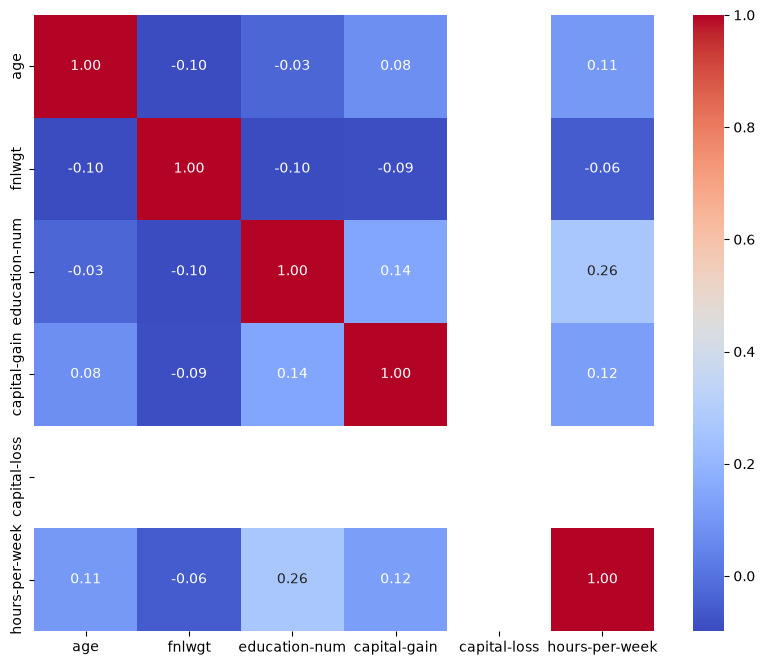

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols + [target_column]].corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [12]:
X = df.drop(columns=[target_column])
y = df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (152, 14)
y shape: (152,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (121, 14)
Test shape: (31, 14)


In [14]:
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Dummy F1 (weighted):", f1_score(y_test, y_pred_dummy, average='weighted'))

Dummy Accuracy: 0.5161290322580645
Dummy F1 (weighted): 0.3514070006863418
